# **Employee Salary, Satisfaction & Attrition Analysis**

Overall project Objectives:

*   Part 1- Build regression models to predict salary
*   Part 2- Develop classification models for attrition prediction
*   Part 3- Extract actionable business insights

### **This is only EDA file for Part 1 of this project - predicting the annual salary of any new added employee**

# 💼 Tech Salary Analysis & Prediction (EDA + Feature Engineering)

## 📌 Objective
In this notebook, we analyze a real-world tech salary dataset to understand:

- What factors influence annual salary?
- How experience, education, and role affect compensation?
- Whether skills and certifications significantly impact salary
- Key patterns in salary distribution across tech fields

## 🎯 Goal
To perform exploratory data analysis (EDA) and feature engineering that can later be used for building a salary prediction model.

## 📊 Dataset Overview
This dataset contains information about employees in the tech industry including:
- Job role and experience
- Education level
- Technical skills
- Company type and work arrangement
- Salary details

In [50]:
#link of Dataset from github
# https://github.com/salonipandagale/Employee-Salary-Satisfaction-Attrition-Analysis/blob/main/archive%20(2).zip

#download zip
!wget "https://github.com/salonipandagale/Employee-Salary-Satisfaction-Attrition-Analysis/raw/main/archive%20(2).zip"

--2026-05-22 13:38:23--  https://github.com/salonipandagale/Employee-Salary-Satisfaction-Attrition-Analysis/raw/main/archive%20(2).zip
Resolving github.com (github.com)... 4.237.22.38
Connecting to github.com (github.com)|4.237.22.38|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/salonipandagale/Employee-Salary-Satisfaction-Attrition-Analysis/main/archive%20(2).zip [following]
--2026-05-22 13:38:23--  https://raw.githubusercontent.com/salonipandagale/Employee-Salary-Satisfaction-Attrition-Analysis/main/archive%20(2).zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1377272 (1.3M) [application/zip]
Saving to: ‘archive (2).zip.2’

archive (2).zip.2   100%[===================>]   1.31M  --.-KB/

# Loading the Dataset
We begin by loading the dataset and taking a quick look at its structure.

In [51]:
# Load
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/mabubakrsiddiq/salary-and-skills-ds-what-factors-increases-salary/tech_salary_dataset.csv")

In [52]:
# lets see the data once
df.head()

,employee_id,first_name,last_name,age,gender,location,currency,primary_tech_field,job_title,employment_type,...,monthly_miscellaneous_usd,monthly_total_expenses_usd,annual_total_expenses_usd,annual_savings_usd,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
0,EMP-00001,Emma,Johansson,32,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,...,417.44,5175.31,62103.72,6271.69,3,12.9,38,1,6,False
1,EMP-00002,Stephanie,Zhang,30,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,...,504.87,10082.84,120994.08,10151.16,4,6.5,26,1,4,False
2,EMP-00003,Raj,Lopez,32,Male,"Amsterdam, Netherlands",EUR,Backend Development,API Engineer,Full-time,...,377.88,8111.78,97341.36,4172.42,5,13.2,0,0,6,True
3,EMP-00004,Amelia,Taylor,31,Female,"London, UK",GBP,Database & Data Engineering,Analytics Engineer,Full-time,...,1140.39,23327.47,279929.64,19102.74,2,5.9,111,5,7,False
4,EMP-00005,Sophia,Gonzalez,42,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,...,844.73,11148.58,133782.96,3308.59,6,0.0,20,3,9,False


# Data Inspection
We inspect the dataset to understand:
- Column types
- Missing values
- Basic statistics

In [53]:
#all columns
df.columns

Index(['employee_id', 'first_name', 'last_name', 'age', 'gender', 'location',
       'currency', 'primary_tech_field', 'job_title', 'employment_type',
       'work_arrangement', 'experience_years_total',
       'experience_years_in_field', 'education_level', 'languages_spoken',
       'skills', 'primary_skill', 'num_skills', 'certifications',
       'company_size', 'annual_salary_usd', 'monthly_salary_usd',
       'hourly_rate_usd', 'annual_bonus_usd', 'bonus_percentage', 'has_equity',
       'equity_total_value_usd', 'equity_vesting_years',
       'effective_tax_rate_pct', 'annual_tax_usd', 'annual_net_salary_usd',
       'monthly_net_salary_usd', 'monthly_housing_usd',
       'monthly_transportation_usd', 'monthly_food_usd',
       'monthly_utilities_usd', 'monthly_healthcare_usd',
       'monthly_entertainment_usd', 'monthly_education_loan_usd',
       'monthly_childcare_usd', 'monthly_miscellaneous_usd',
       'monthly_total_expenses_usd', 'annual_total_expenses_usd',
       'annu

In [54]:
df.describe()

,age,experience_years_total,experience_years_in_field,num_skills,annual_salary_usd,monthly_salary_usd,hourly_rate_usd,annual_bonus_usd,bonus_percentage,equity_total_value_usd,...,monthly_childcare_usd,monthly_miscellaneous_usd,monthly_total_expenses_usd,annual_total_expenses_usd,annual_savings_usd,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,...,10000.000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,31.637600,5.717070,4.019440,5.494200,171786.241744,14315.520181,91.601258,12363.473986,7.214300,28710.88860,...,916.206,818.562067,14148.267573,169779.210876,16530.105659,3.561300,10.581700,34.515400,1.629600,6.974100
std,6.856892,3.689415,2.823968,1.716176,72550.937998,6045.911530,45.335040,10863.881829,5.159558,100995.44362,...,1062.339,477.180884,7668.022002,92016.264021,10854.098074,1.543464,7.590467,32.959976,1.539364,2.157428
min,18.000000,0.500000,0.500000,3.000000,19846.270000,1653.860000,9.540000,0.000000,0.000000,0.00000,...,0.000,20.650000,424.070000,5088.840000,-4103.200000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,2.800000,1.800000,4.000000,121355.045000,10112.925000,61.190000,2282.800000,5.000000,0.00000,...,0.000,497.502500,9118.967500,109427.610000,8731.762500,2.000000,4.500000,8.000000,0.000000,6.000000
50%,32.000000,5.500000,3.600000,5.000000,167055.180000,13921.265000,85.295000,11302.280000,8.000000,0.00000,...,0.000,756.215000,13336.920000,160043.040000,14228.585000,4.000000,10.100000,26.000000,1.000000,7.000000
75%,36.000000,8.200000,5.700000,7.000000,216939.867500,18078.325000,113.770000,18781.787500,10.000000,9773.00000,...,1800.000,1087.377500,18536.777500,222441.330000,21807.995000,5.000000,15.700000,52.000000,2.000000,9.000000
max,58.000000,19.600000,17.800000,8.000000,479033.820000,39919.490000,373.060000,81019.780000,20.000000,995997.00000,...,3600.000,3868.360000,52337.650000,628051.800000,86728.360000,6.000000,54.100000,224.000000,10.000000,10.000000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   employee_id                  10000 non-null  object 
 1   first_name                   10000 non-null  object 
 2   last_name                    10000 non-null  object 
 3   age                          10000 non-null  int64  
 4   gender                       10000 non-null  object 
 5   location                     10000 non-null  object 
 6   currency                     10000 non-null  object 
 7   primary_tech_field           10000 non-null  object 
 8   job_title                    10000 non-null  object 
 9   employment_type              10000 non-null  object 
 10  work_arrangement             10000 non-null  object 
 11  experience_years_total       10000 non-null  float64
 12  experience_years_in_field    10000 non-null  float64
 13  education_level  

In [56]:
#lets create a copy ,original dataset can be used in other files as well
new_df= df.copy()

In [57]:
new_df.head()

,employee_id,first_name,last_name,age,gender,location,currency,primary_tech_field,job_title,employment_type,...,monthly_miscellaneous_usd,monthly_total_expenses_usd,annual_total_expenses_usd,annual_savings_usd,vacation_weeks,overtime_hours_per_month,months_since_last_promotion,num_previous_companies,job_satisfaction_score,is_actively_looking
0,EMP-00001,Emma,Johansson,32,Female,Remote (Global),USD,Backend Development,Platform Engineer,Full-time,...,417.44,5175.31,62103.72,6271.69,3,12.9,38,1,6,False
1,EMP-00002,Stephanie,Zhang,30,Female,"Seattle, USA",USD,QA & Testing,QA Engineer,Full-time,...,504.87,10082.84,120994.08,10151.16,4,6.5,26,1,4,False
2,EMP-00003,Raj,Lopez,32,Male,"Amsterdam, Netherlands",EUR,Backend Development,API Engineer,Full-time,...,377.88,8111.78,97341.36,4172.42,5,13.2,0,0,6,True
3,EMP-00004,Amelia,Taylor,31,Female,"London, UK",GBP,Database & Data Engineering,Analytics Engineer,Full-time,...,1140.39,23327.47,279929.64,19102.74,2,5.9,111,5,7,False
4,EMP-00005,Sophia,Gonzalez,42,Female,"Boston, USA",USD,Embedded Systems & IoT,Embedded Engineer,Full-time,...,844.73,11148.58,133782.96,3308.59,6,0.0,20,3,9,False


In [58]:
new_df.columns

Index(['employee_id', 'first_name', 'last_name', 'age', 'gender', 'location',
       'currency', 'primary_tech_field', 'job_title', 'employment_type',
       'work_arrangement', 'experience_years_total',
       'experience_years_in_field', 'education_level', 'languages_spoken',
       'skills', 'primary_skill', 'num_skills', 'certifications',
       'company_size', 'annual_salary_usd', 'monthly_salary_usd',
       'hourly_rate_usd', 'annual_bonus_usd', 'bonus_percentage', 'has_equity',
       'equity_total_value_usd', 'equity_vesting_years',
       'effective_tax_rate_pct', 'annual_tax_usd', 'annual_net_salary_usd',
       'monthly_net_salary_usd', 'monthly_housing_usd',
       'monthly_transportation_usd', 'monthly_food_usd',
       'monthly_utilities_usd', 'monthly_healthcare_usd',
       'monthly_entertainment_usd', 'monthly_education_loan_usd',
       'monthly_childcare_usd', 'monthly_miscellaneous_usd',
       'monthly_total_expenses_usd', 'annual_total_expenses_usd',
       'annu

# Data Cleaning & Feature Selection
We remove irrelevant columns that do not contribute to salary prediction such as personal identifiers and derived financial fields.

This helps reduce noise and improves model performance later.

In [59]:
# lets check if there are any duplicates
new_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [60]:
#as this dataset we want to use for annual salary prediction, lets drop the columns which are not necessary for Salary prediction

new_df= new_df.drop(columns=["employee_id", 'first_name', 'last_name','location', 'currency','monthly_salary_usd',
       'hourly_rate_usd', 'annual_bonus_usd', 'bonus_percentage','has_equity',
       'equity_total_value_usd', 'equity_vesting_years',
       'effective_tax_rate_pct', 'annual_tax_usd', 'annual_net_salary_usd',
       'monthly_net_salary_usd', 'monthly_housing_usd',
       'monthly_transportation_usd', 'monthly_food_usd',
       'monthly_utilities_usd', 'monthly_healthcare_usd',
       'monthly_entertainment_usd', 'monthly_education_loan_usd',
       'monthly_childcare_usd', 'monthly_miscellaneous_usd',
       'monthly_total_expenses_usd', 'annual_total_expenses_usd',
       'annual_savings_usd', 'vacation_weeks', 'overtime_hours_per_month',
       'months_since_last_promotion', 'num_previous_companies',
       'job_satisfaction_score', 'is_actively_looking'])

In [61]:
# lets see how dataset looks after deleting columns
new_df.head()

,age,gender,primary_tech_field,job_title,employment_type,work_arrangement,experience_years_total,experience_years_in_field,education_level,languages_spoken,skills,primary_skill,num_skills,certifications,company_size,annual_salary_usd
0,32,Female,Backend Development,Platform Engineer,Full-time,Remote,7.7,3.2,Associate's Degree,English,Spring Boot; PHP; Python,Spring Boot,3,NaN,Small (11-50),100290.66
1,30,Female,QA & Testing,QA Engineer,Full-time,On-site,3.0,1.9,Bootcamp,English; Telugu,PyTest; API Testing; Cypress; JUnit; Postman; ...,PyTest,8,NaN,Startup (1-10),92383.12
2,32,Male,Backend Development,API Engineer,Full-time,Remote,0.5,0.5,Bachelor's Degree,English; German; Spanish; Dutch,PHP; Express.js; Java; Rust; Spring Boot; C#; ...,PHP,8,AWS Certified Solutions Architect,Enterprise (1000+),107153.59
3,31,Female,Database & Data Engineering,Analytics Engineer,Full-time,Hybrid,14.5,12.4,Bootcamp,English; German; Mandarin,Snowflake; Elasticsearch; Cassandra; dbt,Snowflake,4,Linux Foundation Certified,Medium (51-200),217074.54
4,42,Female,Embedded Systems & IoT,Embedded Engineer,Full-time,Fully Remote,7.9,3.8,Bootcamp,English; Telugu,RTOS; ARM; PCB Design; Embedded Linux,RTOS,4,NaN,Startup (1-10),152246.34


# Handling Missing Values
We observe missing values in the dataset, especially in the `certifications` column.

We will handle these during feature engineering by treating missing or "None" values as zero certifications.

In [62]:
new_df.isnull().sum()

age                             0
gender                          0
primary_tech_field              0
job_title                       0
employment_type                 0
work_arrangement                0
experience_years_total          0
experience_years_in_field       0
education_level                 0
languages_spoken                0
skills                          0
primary_skill                   0
num_skills                      0
certifications               4508
company_size                    0
annual_salary_usd               0
dtype: int64

we have some null values in certifications which we will handle further.

### Now lets check what are the various categories in categorical columns and their counts

In [63]:

print("value counts for company size : \n", new_df['company_size'].value_counts())
print()
print("value counts for employment_type :\n ", new_df['employment_type'].value_counts())
print()
print("value counts for primary_tech_field :\n ", new_df['primary_tech_field'].value_counts())
print()
print("value counts for work_arrangement : \n", new_df['work_arrangement'].value_counts())
print()
print("value counts for job_title : \n", new_df['job_title'].value_counts())

value counts for company size : 
 company_size
Enterprise (1000+)    2047
Medium (51-200)       2021
Large (201-1000)      2002
Startup (1-10)        1988
Small (11-50)         1942
Name: count, dtype: int64

value counts for employment_type :
  employment_type
Full-time    8011
Contract      992
Freelance     691
Part-time     306
Name: count, dtype: int64

value counts for primary_tech_field :
  primary_tech_field
Full-Stack Development          1233
Data Science & ML               1053
Backend Development             1047
Frontend Development             916
Product Management               826
DevOps & Cloud                   783
Mobile Development               700
QA & Testing                     618
Database & Data Engineering      568
Embedded Systems & IoT           507
Cybersecurity                    487
Site Reliability Engineering     460
Game Development                 412
Blockchain & Web3                390
Name: count, dtype: int64

value counts for work_arrangement :



*   Fully remote = remote, so lets do the changes in column
*   job title has many categories , lets keep the first five categories and change rest to 'other'



In [64]:
new_df['work_arrangement']=new_df['work_arrangement'].replace({'Fully Remote' : 'Remote'})


In [65]:
#lets check if it is done
new_df['work_arrangement'].value_counts()

work_arrangement
Remote     5631
Hybrid     2778
On-site    1591
Name: count, dtype: int64

### Handling Rare Job Titles

The dataset contains many job titles with very few samples.

To reduce noise and improve generalization, we group all rare job titles (frequency < 240) into a single category called **"Other"**.

In [66]:
counts_job_title =new_df['job_title'].value_counts()
rare_job_title = counts_job_title[counts_job_title < 240].index

new_df['job_title']=new_df['job_title'].replace(rare_job_title, 'Other')

In [67]:
#let's check
new_df['job_title'].value_counts()

job_title
Other                       8525
Platform Engineer            363
Web Developer                363
Senior Software Engineer     256
Full Stack Developer         252
Software Engineer            241
Name: count, dtype: int64

### lets create few new columns :

1. count of certificates for each emp
2. count of language for each emp
3. sum of skills and certification for each emp

#  Feature Engineering

We create new features to better represent employee skills:

### 1. Number of Languages
We convert the `languages_spoken` column into a numeric feature representing how many languages an employee speaks.

This helps quantify communication diversity.

### 2. Number of Certifications
We extract the number of certifications from a semi-colon separated string.

Missing or "None" values are treated as zero.

### 3. Total Skills + Certifications
We combine skills and certifications into a single feature to represent overall technical strength.

This gives a more holistic view of an employee's capabilities.

In [68]:
#Language column has many language seperated by colon, we need to count languages spoken by each employee in different coulumn

new_df['num_languages'] = new_df['languages_spoken'].fillna('').apply(
    lambda x: 0 if x.strip() == '' else len([lang.strip() for lang in x.split(';')]))

# same for certificate
new_df['num_certifications'] = new_df['certifications'].fillna('').apply(
    lambda x: 0 if (x.strip() == '' or x.strip().lower() == 'none')
    else len([c.strip() for c in x.split(';')])
)


In [69]:
#lets create a new column that sums no.of skills and no.of certifications for each employee

new_df['total_skills + certificates'] = new_df['num_skills']+new_df['num_certifications']

In [70]:
new_df.head()

,age,gender,primary_tech_field,job_title,employment_type,work_arrangement,experience_years_total,experience_years_in_field,education_level,languages_spoken,skills,primary_skill,num_skills,certifications,company_size,annual_salary_usd,num_languages,num_certifications,total_skills + certificates
0,32,Female,Backend Development,Platform Engineer,Full-time,Remote,7.7,3.2,Associate's Degree,English,Spring Boot; PHP; Python,Spring Boot,3,NaN,Small (11-50),100290.66,1,0,3
1,30,Female,QA & Testing,Other,Full-time,On-site,3.0,1.9,Bootcamp,English; Telugu,PyTest; API Testing; Cypress; JUnit; Postman; ...,PyTest,8,NaN,Startup (1-10),92383.12,2,0,8
2,32,Male,Backend Development,Other,Full-time,Remote,0.5,0.5,Bachelor's Degree,English; German; Spanish; Dutch,PHP; Express.js; Java; Rust; Spring Boot; C#; ...,PHP,8,AWS Certified Solutions Architect,Enterprise (1000+),107153.59,4,1,9
3,31,Female,Database & Data Engineering,Other,Full-time,Hybrid,14.5,12.4,Bootcamp,English; German; Mandarin,Snowflake; Elasticsearch; Cassandra; dbt,Snowflake,4,Linux Foundation Certified,Medium (51-200),217074.54,3,1,5
4,42,Female,Embedded Systems & IoT,Other,Full-time,Remote,7.9,3.8,Bootcamp,English; Telugu,RTOS; ARM; PCB Design; Embedded Linux,RTOS,4,NaN,Startup (1-10),152246.34,2,0,4


In [71]:
new_df['total_skills + certificates'].dtype

dtype('int64')

# **Lets do visualization**

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
# lets find the correlation of all the features with annual_salary_usd
new_df.corr(numeric_only=True)['annual_salary_usd'].sort_values(ascending=True)

total_skills + certificates   -0.010614
num_skills                    -0.009723
num_certifications            -0.004415
age                           -0.002811
num_languages                  0.000831
experience_years_in_field      0.402285
experience_years_total         0.444732
annual_salary_usd              1.000000
Name: annual_salary_usd, dtype: float64

<Axes: >

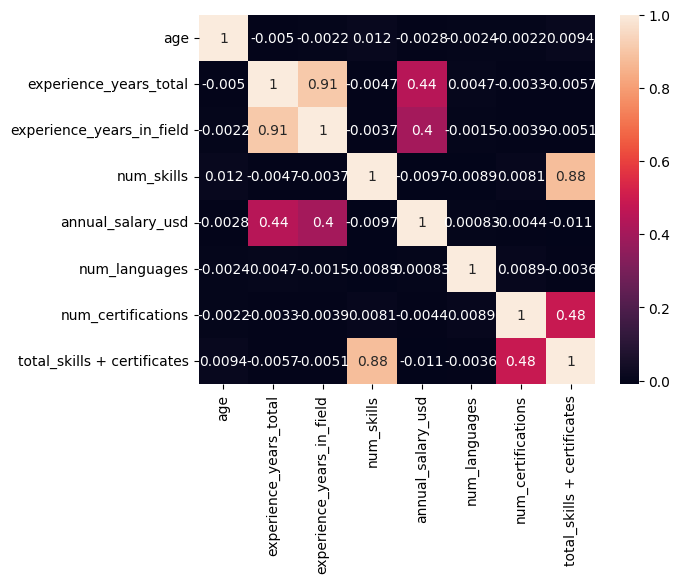

In [74]:
sns.heatmap(new_df.corr(numeric_only=True), annot=True)

## Univariate Analysis

We first analyze individual feature distributions to understand:
- Salary distribution
- Experience distribution
- Frequency of categories

Text(0.5, 1.0, 'Distribution of Annual Salary')

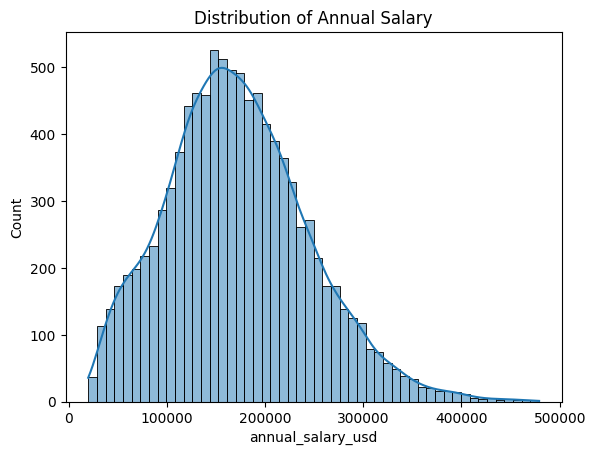

In [75]:
sns.histplot(new_df['annual_salary_usd'], kde=True)
plt.title("Distribution of Annual Salary")

<Axes: xlabel='experience_years_total', ylabel='Count'>

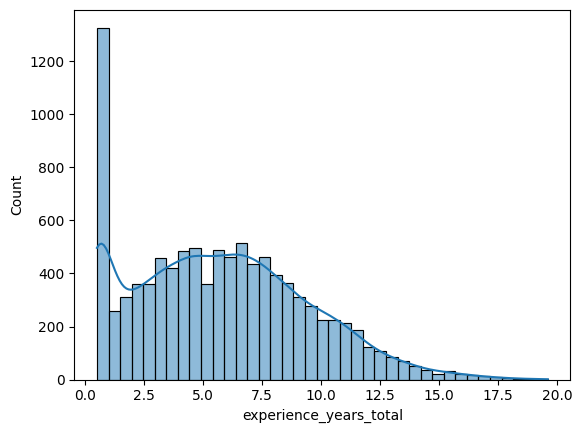

In [76]:
sns.histplot(new_df['experience_years_total'], kde=True)

<Axes: xlabel='num_skills', ylabel='count'>

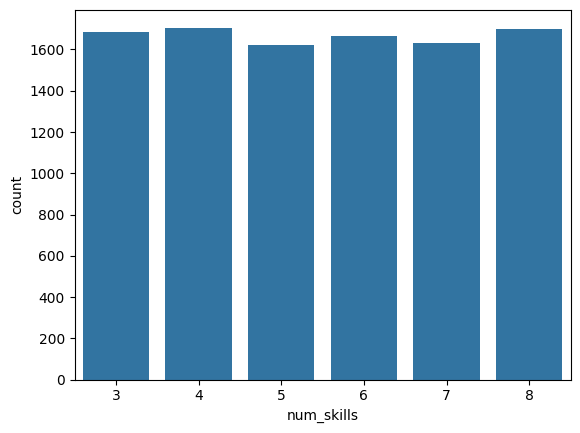

In [77]:
sns.countplot(x='num_skills', data=new_df)

<Axes: xlabel='num_certifications', ylabel='count'>

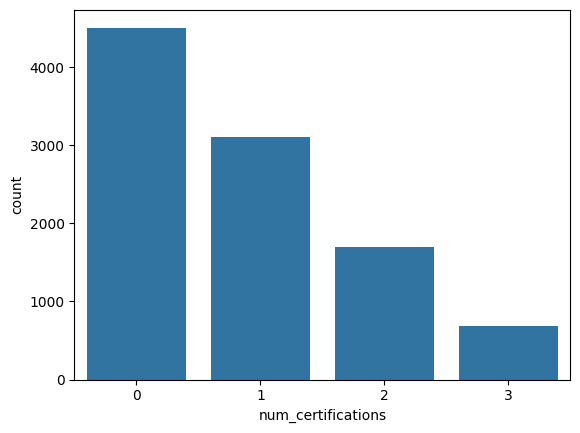

In [78]:
sns.countplot(x='num_certifications', data=new_df)

Text(0.5, 1.0, 'Work Arrangement')

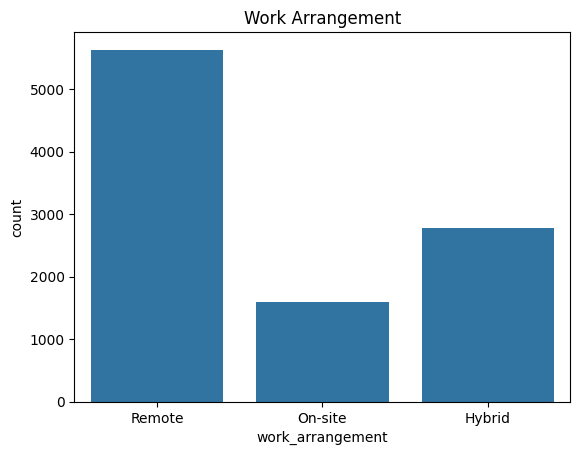

In [79]:
sns.countplot(x='work_arrangement', data=new_df)
plt.title('Work Arrangement')

Work arrangement shows limited impact on salary, indicating that compensation is more role-dependent than location-dependent.

([0, 1, 2, 3],
 [Text(0, 0, 'Full-time'),
  Text(1, 0, 'Contract'),
  Text(2, 0, 'Freelance'),
  Text(3, 0, 'Part-time')])

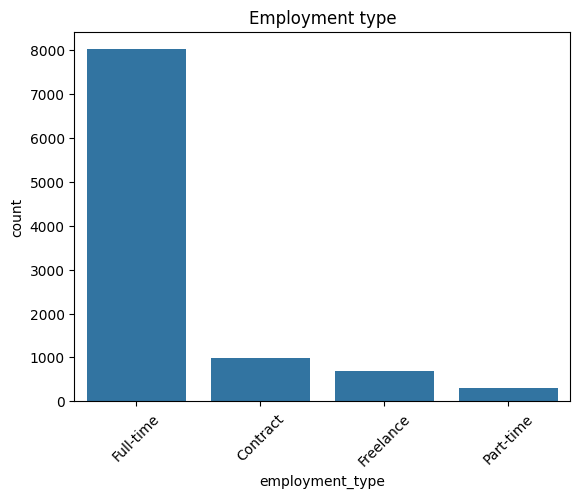

In [80]:
sns.countplot(x='employment_type', data=new_df)
plt.title('Employment type')
plt.xticks(rotation=45)

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Small (11-50)'),
  Text(1, 0, 'Startup (1-10)'),
  Text(2, 0, 'Enterprise (1000+)'),
  Text(3, 0, 'Medium (51-200)'),
  Text(4, 0, 'Large (201-1000)')])

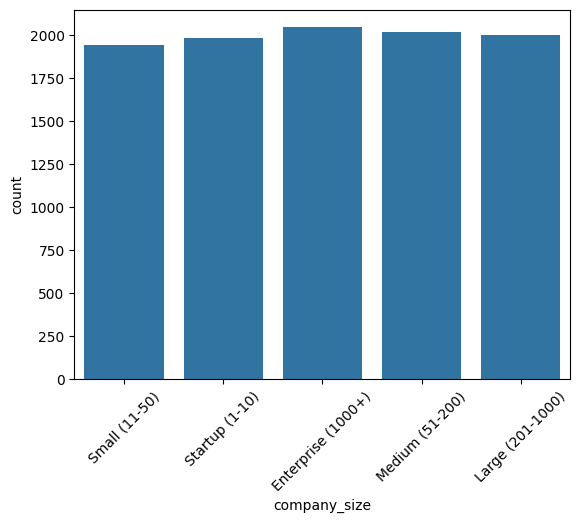

In [81]:
sns.countplot(x='company_size', data=new_df)
plt.xticks(rotation=45)

<Axes: xlabel='count', ylabel='primary_tech_field'>

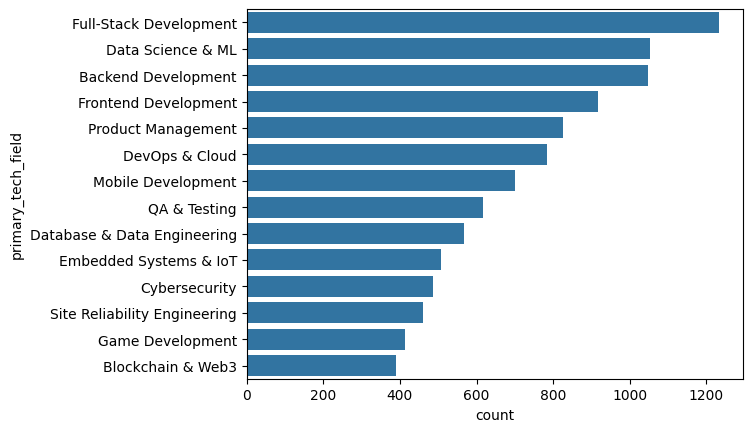

In [82]:
sns.countplot(y='primary_tech_field', data=new_df, order=new_df['primary_tech_field'].value_counts().index)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, "Associate's Degree"),
  Text(1, 0, 'Bootcamp'),
  Text(2, 0, "Bachelor's Degree"),
  Text(3, 0, "Master's Degree"),
  Text(4, 0, 'PhD'),
  Text(5, 0, 'High School')])

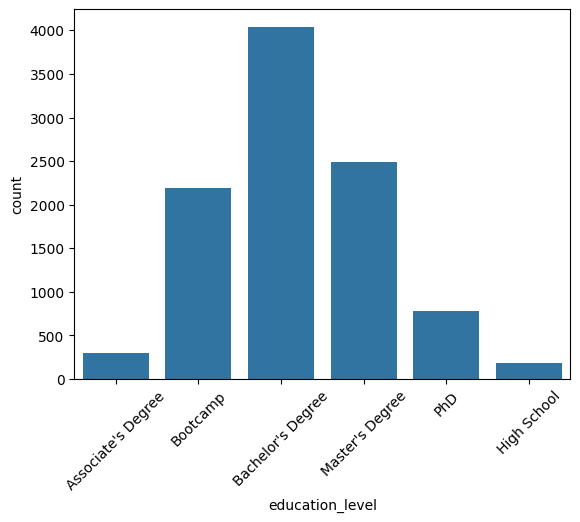

In [83]:
sns.countplot(x='education_level', data=new_df)
plt.xticks(rotation=45)

## Bivariate Analysis

<Axes: xlabel='num_skills', ylabel='annual_salary_usd'>

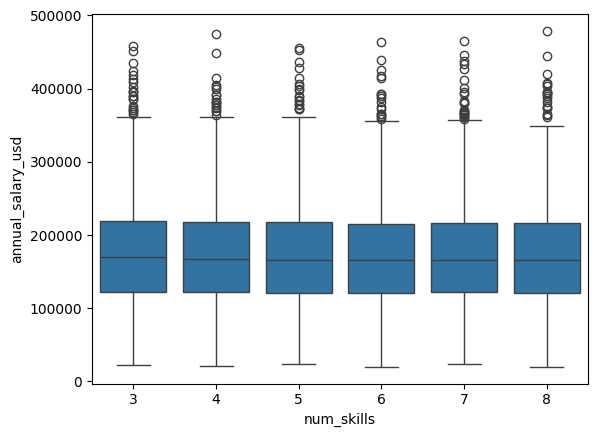

In [84]:
sns.boxplot(data =new_df, x='num_skills', y= 'annual_salary_usd')

<Axes: xlabel='num_certifications', ylabel='annual_salary_usd'>

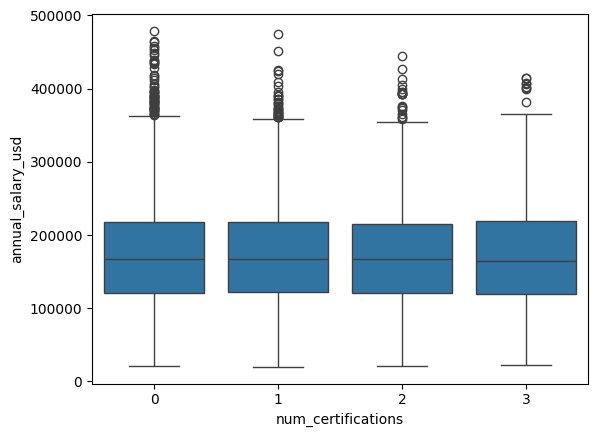

In [85]:
sns.boxplot(data =new_df, x='num_certifications', y= 'annual_salary_usd')

### Conclusion from above graphs
The number of skills and certifications shows weak correlation with salary. This suggests that salary is not driven by quantity of skills, but likely by skill relevance, job role, experience, and domain expertise

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Backend Development'),
  Text(1, 0, 'QA & Testing'),
  Text(2, 0, 'Database & Data Engineering'),
  Text(3, 0, 'Embedded Systems & IoT'),
  Text(4, 0, 'Game Development'),
  Text(5, 0, 'Site Reliability Engineering'),
  Text(6, 0, 'Full-Stack Development'),
  Text(7, 0, 'Mobile Development'),
  Text(8, 0, 'Product Management'),
  Text(9, 0, 'Cybersecurity'),
  Text(10, 0, 'Data Science & ML'),
  Text(11, 0, 'DevOps & Cloud'),
  Text(12, 0, 'Blockchain & Web3'),
  Text(13, 0, 'Frontend Development')])

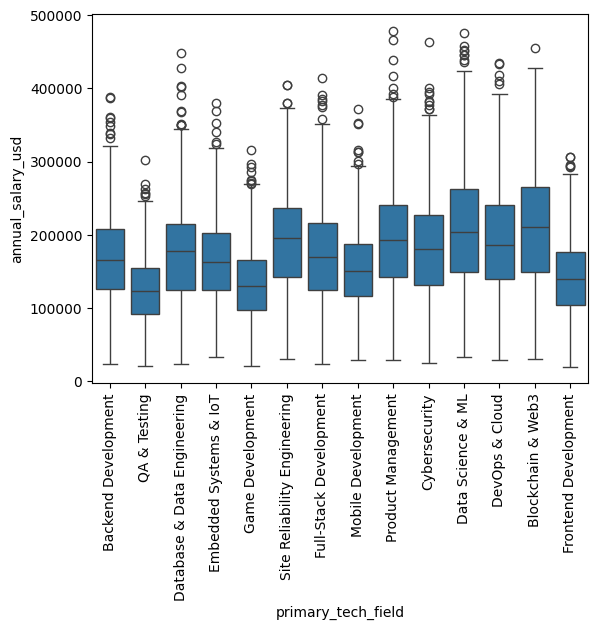

In [86]:
sns.boxplot(data=new_df,
            x='primary_tech_field',
            y='annual_salary_usd',
           )
plt.xticks(rotation=90)

### Conclusion from above graphs
Primary tech field shows variation in salary distribution. Fields like Data Science & ML, DevOps, Cloud, and Blockchain tend to have higher median salaries and also exhibit higher variability with significant outliers, suggesting presence of senior/high-paying roles in these domains.

In [87]:

print("The columns are :", new_df.columns)

The columns are : Index(['age', 'gender', 'primary_tech_field', 'job_title', 'employment_type',
       'work_arrangement', 'experience_years_total',
       'experience_years_in_field', 'education_level', 'languages_spoken',
       'skills', 'primary_skill', 'num_skills', 'certifications',
       'company_size', 'annual_salary_usd', 'num_languages',
       'num_certifications', 'total_skills + certificates'],
      dtype='object')


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, "Associate's Degree"),
  Text(1, 0, 'Bootcamp'),
  Text(2, 0, "Bachelor's Degree"),
  Text(3, 0, "Master's Degree"),
  Text(4, 0, 'PhD'),
  Text(5, 0, 'High School')])

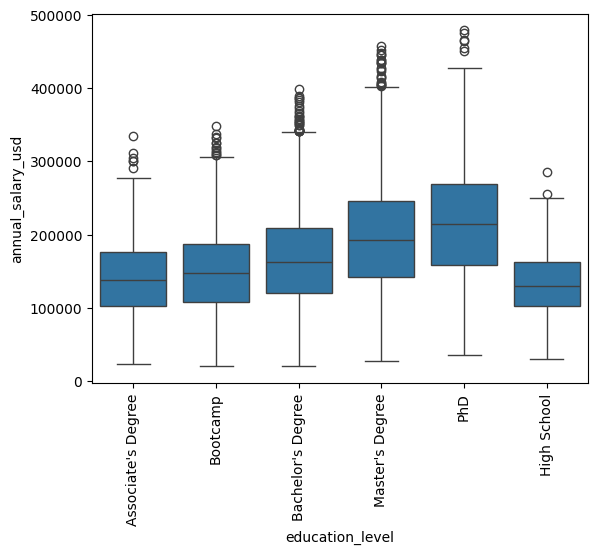

In [88]:
sns.boxplot(data= new_df, x='education_level', y='annual_salary_usd')
plt.xticks(rotation=90)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Backend Development'),
  Text(1, 0, 'QA & Testing'),
  Text(2, 0, 'Database & Data Engineering'),
  Text(3, 0, 'Embedded Systems & IoT'),
  Text(4, 0, 'Game Development'),
  Text(5, 0, 'Site Reliability Engineering'),
  Text(6, 0, 'Full-Stack Development'),
  Text(7, 0, 'Mobile Development'),
  Text(8, 0, 'Product Management'),
  Text(9, 0, 'Cybersecurity'),
  Text(10, 0, 'Data Science & ML'),
  Text(11, 0, 'DevOps & Cloud'),
  Text(12, 0, 'Blockchain & Web3'),
  Text(13, 0, 'Frontend Development')])

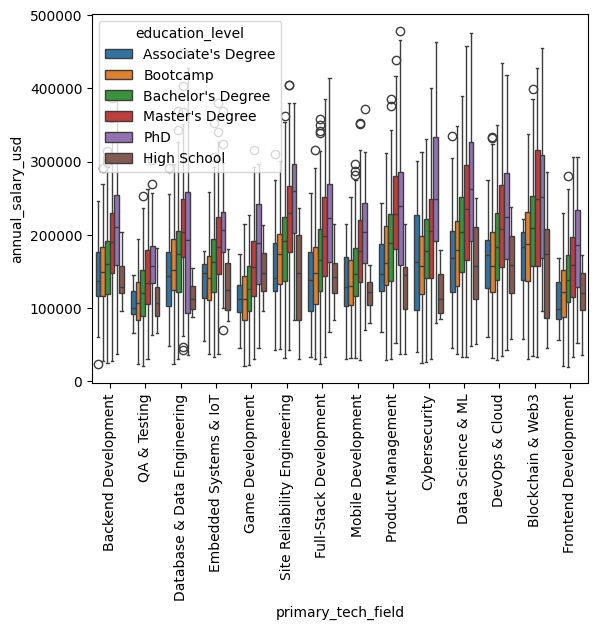

In [89]:
sns.boxplot(data=new_df, x='primary_tech_field', y='annual_salary_usd', hue='education_level')
plt.xticks(rotation = 90)

### Conclusion from above graph

Employees with Bachelor's degree , Master's Degree, PHD have more annual salary than others, Especially masters and phd employees . So we say higher education leads to better salary.

<Axes: xlabel='experience_years_in_field', ylabel='annual_salary_usd'>

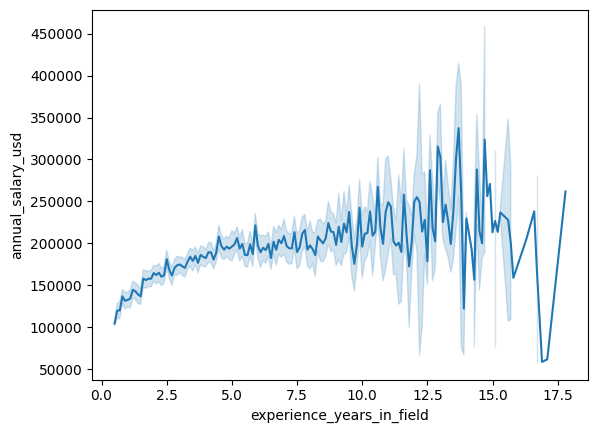

In [90]:
sns.lineplot(data=new_df, x='experience_years_in_field', y='annual_salary_usd')

<Axes: xlabel='employment_type', ylabel='annual_salary_usd'>

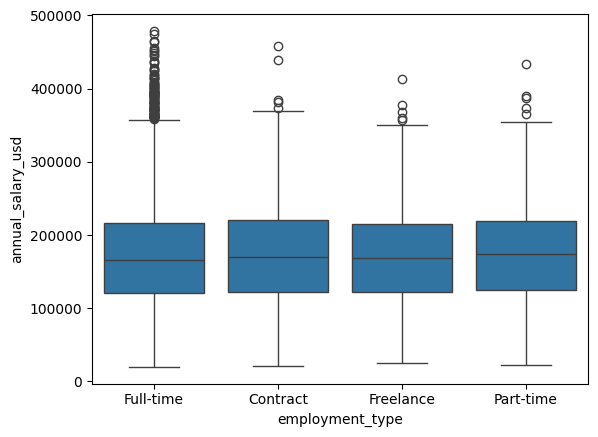

In [91]:
sns.boxplot(data=new_df, x='employment_type', y='annual_salary_usd',)


### Conclusion from above graphs

Employees engaged in Full time role are earning high, as large number of outlers can be seen in full time. However median for cntract based employees is higher.

In [92]:
new_df.groupby('primary_tech_field')['annual_salary_usd'].mean().sort_values()

primary_tech_field
QA & Testing                    124592.403414
Game Development                132452.813155
Frontend Development            140888.723592
Mobile Development              153689.591129
Embedded Systems & IoT          163326.822604
Backend Development             166564.289561
Full-Stack Development          171432.290073
Database & Data Engineering     175232.210634
Cybersecurity                   180965.063881
DevOps & Cloud                  188979.001418
Product Management              192363.929516
Site Reliability Engineering    192762.243804
Data Science & ML               205497.968044
Blockchain & Web3               208965.144821
Name: annual_salary_usd, dtype: float64

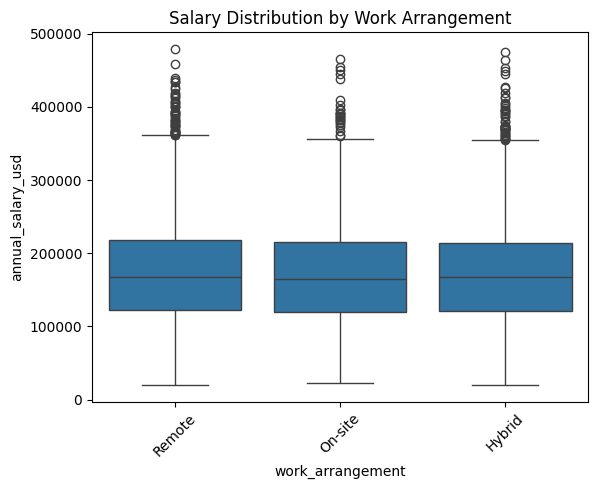

In [93]:
sns.boxplot(data=new_df, x='work_arrangement', y='annual_salary_usd')

plt.title('Salary Distribution by Work Arrangement')
plt.xticks(rotation=45)
plt.show()

1. The analysis shows that primary tech field has a noticeable impact on salary distribution. Fields such as Data Science & ML, DevOps & Cloud, and Blockchain exhibit higher median salaries along with a wider spread and significant outliers, indicating the presence of high-paying senior roles in these domains. However, this does not imply causation, as salary is also influenced by factors like experience, job role, and company size.
2. Also we observe that Work arrangement does not affect the amount of salary earned by employee much.

#  Final Summary

Through this analysis, we found that:

- Experience and tech field are strong salary drivers
- Education has moderate impact on salary
- Skills count alone is not a strong predictor of salary
- Salary distribution is highly skewed, with a few high earners

These insights can now be used for building a predictive machine learning model.